# OCM 3x 40iter Best-so-far

这个 notebook 读取 `outputs/ocm_3x_40iter` 下三次实验的 `experiment_records.csv`，
计算 `Performance` 的累计最优值（best-so-far），并画出每次实验曲线与均值曲线。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def resolve_output_root() -> Path:
    candidates = [
        Path('outputs/ocm_3x_40iter'),
        Path('../outputs/ocm_3x_40iter'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Cannot find outputs/ocm_3x_40iter. Please check your working directory.')


OUTPUT_ROOT = resolve_output_root()
RUN_DIRS = sorted(OUTPUT_ROOT.glob('*_run*/'))
METRIC_COL = 'Performance'

print('OUTPUT_ROOT =', OUTPUT_ROOT)
print('Found runs:')
for run_dir in RUN_DIRS:
    print(' -', run_dir.name)


OUTPUT_ROOT = /home/sjtu/LLMBO/ChemBO-Agent/outputs/ocm_3x_40iter
Found runs:
 - kimi-k2.5_ocm_3x_40iter_OCM_run01
 - kimi-k2.5_ocm_3x_40iter_OCM_run02
 - kimi-k2.5_ocm_3x_40iter_OCM_run03


In [3]:
def load_best_so_far(csv_path: Path, metric_col: str = METRIC_COL) -> pd.DataFrame:
    df = pd.read_csv(csv_path).copy()
    if metric_col not in df.columns:
        raise KeyError(f'{metric_col!r} not found in {csv_path.name}. Available columns: {list(df.columns)}')

    values = pd.to_numeric(df[metric_col], errors='coerce')
    clean = pd.DataFrame({
        'iteration': range(1, len(values) + 1),
        'observed': values,
    }).dropna(subset=['observed'])
    clean['best_so_far'] = clean['observed'].cummax()
    return clean


run_frames = {}
for run_dir in RUN_DIRS:
    csv_path = run_dir / 'experiment_records.csv'
    run_frames[run_dir.name] = load_best_so_far(csv_path)

summary_rows = []
for run_name, frame in run_frames.items():
    best_idx = frame['observed'].idxmax()
    summary_rows.append({
        'run': run_name,
        'n_points': len(frame),
        'final_best_so_far': frame['best_so_far'].iloc[-1],
        'best_iteration': int(frame.loc[best_idx, 'iteration']),
        'best_observed': frame.loc[best_idx, 'observed'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('run').reset_index(drop=True)
summary_df

,run,n_points,final_best_so_far,best_iteration,best_observed
0,kimi-k2.5_ocm_3x_40iter_OCM_run01,40,18.724106,30,18.724106
1,kimi-k2.5_ocm_3x_40iter_OCM_run02,40,46.414758,18,46.414758
2,kimi-k2.5_ocm_3x_40iter_OCM_run03,40,70.414491,40,70.414491


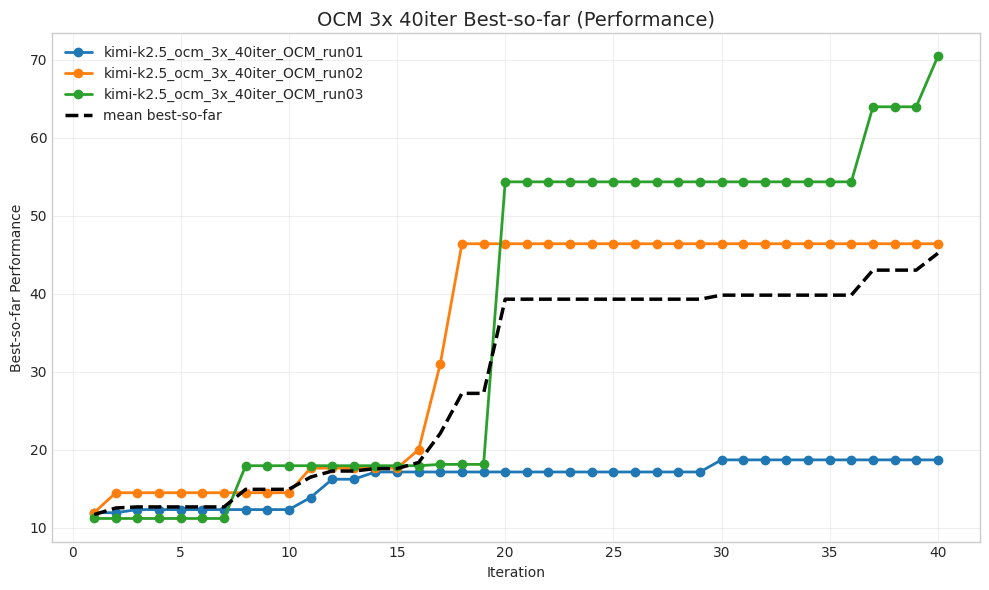

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

combined = None
for run_name, frame in run_frames.items():
    ax.plot(frame['iteration'], frame['best_so_far'], marker='o', linewidth=2, label=run_name)

    series = frame.set_index('iteration')['best_so_far'].rename(run_name)
    if combined is None:
        combined = pd.DataFrame(series)
    else:
        combined = combined.join(series, how='outer')

mean_curve = combined.sort_index().ffill().mean(axis=1)
ax.plot(mean_curve.index, mean_curve.values, color='black', linestyle='--', linewidth=2.5, label='mean best-so-far')

ax.set_title('OCM 3x 40iter Best-so-far (Performance)', fontsize=14)
ax.set_xlabel('Iteration')
ax.set_ylabel('Best-so-far Performance')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [6]:
save_candidates = [Path('plot'), Path('.')]
save_dir = next((path for path in save_candidates if path.exists()), Path('.'))
save_path = (save_dir / 'ocm_3x_40iter_best_so_far.png').resolve()
print(save_path)
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print('Saved figure to:', save_path)

/home/sjtu/LLMBO/ChemBO-Agent/plot/ocm_3x_40iter_best_so_far.png
Saved figure to: /home/sjtu/LLMBO/ChemBO-Agent/plot/ocm_3x_40iter_best_so_far.png
